In [1]:
import os
import io
import json
import time
import math
import glob
import hashlib
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve, auc
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.19.0
Num GPUs Available: 0


In [2]:
# =========================
# MAIN CONFIGURATION
# =========================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Because you are opening the notebook inside your current project folder,
# this will create the new folder 19042026 inside that folder.
PROJECT_ROOT = Path.cwd() / "19042026"
EXP_ROOT = PROJECT_ROOT / "E00_hyperparameter_tuning"

# Existing project data paths
TRAIN_DIR = Path.cwd() / "train"

# Tries to locate your metadata file automatically
metadata_candidates = list(Path.cwd().glob("Metadata_ISIC_2020_Training_GroundTruth_v2*"))
if len(metadata_candidates) == 0:
    raise FileNotFoundError("Metadata file not found. Make sure it is in the current folder.")
METADATA_PATH = metadata_candidates[0]

# Image / split settings
IMG_SIZE = (224, 224)
TEST_SIZE = 0.10
VAL_SIZE = 0.10   # final val proportion from full dataset
BATCH_EXTRACT = 32
THRESHOLD = 0.50

# Preprocessing switches
USE_HAIR_REMOVAL = True
USE_SEGMENTATION = False   # keep False in E00
SAVE_SAMPLE_PREPROCESSING = True
N_SAMPLE_PREPROCESSING = 12

# Hyperparameter search space (keep small for laptop)
HYPERPARAM_GRID = [
    {"dense_units": 128, "dropout": 0.50, "lr": 1e-4, "batch_size": 32, "epochs": 15},
    {"dense_units": 64,  "dropout": 0.50, "lr": 1e-4, "batch_size": 32, "epochs": 15},
    {"dense_units": 128, "dropout": 0.30, "lr": 5e-5, "batch_size": 32, "epochs": 15},
    {"dense_units": 256, "dropout": 0.40, "lr": 5e-5, "batch_size": 16, "epochs": 15},
]

# Selection metric for best config
BEST_BY = "f1"   # options: accuracy, precision, recall, f1, kappa, roc_auc

print("PROJECT_ROOT:", PROJECT_ROOT)
print("EXP_ROOT:", EXP_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("METADATA_PATH:", METADATA_PATH)

PROJECT_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026
EXP_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E00_hyperparameter_tuning
TRAIN_DIR: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\train
METADATA_PATH: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\Metadata_ISIC_2020_Training_GroundTruth_v2.csv


In [3]:
# =========================
# CREATE FOLDER STRUCTURE
# =========================

SUBDIRS = [
    "configs",
    "models",
    "histories",
    "metrics",
    "predictions",
    "plots",
    "confusion_matrices",
    "feature_cache",
    "logs",
    "summary",
    "preprocessing_samples"
]

for sub in SUBDIRS:
    (EXP_ROOT / sub).mkdir(parents=True, exist_ok=True)

print("Folders created under:", EXP_ROOT)

Folders created under: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E00_hyperparameter_tuning


In [4]:
# =========================
# HELPER FUNCTIONS
# =========================

def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4)

def compute_md5(file_path, chunk_size=8192):
    h = hashlib.md5()
    with open(file_path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def verify_image(file_path):
    try:
        with Image.open(file_path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError, IOError):
        return False

def remove_hairs_bgr(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    cleaned = cv2.inpaint(img_bgr, mask, 1, cv2.INPAINT_TELEA)
    return cleaned, mask

def simple_segment_lesion(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return img_bgr, thresh

    largest = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [largest], -1, 255, thickness=-1)

    segmented = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)

    x, y, w, h = cv2.boundingRect(largest)
    if w > 0 and h > 0:
        crop = segmented[y:y+h, x:x+w]
    else:
        crop = segmented

    return crop, mask

def preprocess_image_for_resnet(path, img_size=(224, 224), use_hair_removal=False, use_segmentation=False):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise ValueError(f"Could not read image: {path}")

    original = img_bgr.copy()

    hair_mask = None
    seg_mask = None

    if use_hair_removal:
        img_bgr, hair_mask = remove_hairs_bgr(img_bgr)

    if use_segmentation:
        img_bgr, seg_mask = simple_segment_lesion(img_bgr)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, img_size, interpolation=cv2.INTER_AREA)
    img_arr = np.asarray(img_rgb, dtype=np.float32)
    img_arr = preprocess_input(img_arr)

    return img_arr, original, hair_mask, seg_mask

def plot_and_save_confusion(cm, labels, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

def plot_history(history, save_dir, run_name):
    hist = pd.DataFrame(history.history)

    if "accuracy" in hist.columns:
        plt.figure(figsize=(7, 5))
        plt.plot(hist["accuracy"], label="Train Accuracy")
        plt.plot(hist["val_accuracy"], label="Val Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(f"Training vs Validation Accuracy - {run_name}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(save_dir / f"{run_name}_accuracy.png", dpi=300, bbox_inches="tight")
        plt.close()

    if "loss" in hist.columns:
        plt.figure(figsize=(7, 5))
        plt.plot(hist["loss"], label="Train Loss")
        plt.plot(hist["val_loss"], label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"Training vs Validation Loss - {run_name}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(save_dir / f"{run_name}_loss.png", dpi=300, bbox_inches="tight")
        plt.close()

def plot_roc_and_pr(y_true, y_prob, run_name, save_dir):
    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {run_name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_roc.png", dpi=300, bbox_inches="tight")
    plt.close()

    # PR
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {run_name}")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_pr.png", dpi=300, bbox_inches="tight")
    plt.close()

def build_head_model(feature_dim, dense_units=128, dropout=0.5, lr=1e-4):
    model = keras.Sequential([
        layers.Input(shape=(feature_dim,)),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def evaluate_binary(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    try:
        roc = roc_auc_score(y_true, y_prob)
    except:
        roc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "kappa": float(kappa),
        "roc_auc": float(roc) if not np.isnan(roc) else None,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold)
    }

In [5]:
# =========================
# LOAD METADATA
# =========================

if METADATA_PATH.suffix.lower() in [".xlsx", ".xls"]:
    df = pd.read_excel(METADATA_PATH)
elif METADATA_PATH.suffix.lower() in [".csv", ".txt"]:
    df = pd.read_csv(METADATA_PATH)
else:
    raise ValueError(f"Unsupported metadata format: {METADATA_PATH.suffix}")

print("Metadata shape:", df.shape)
print("Columns:", df.columns.tolist())

# Resolve image name column
image_col_candidates = ["image_name", "image", "image_id", "isic_id"]
label_col_candidates = ["target", "melanoma", "label"]

image_col = next((c for c in image_col_candidates if c in df.columns), None)
label_col = next((c for c in label_col_candidates if c in df.columns), None)

if image_col is None or label_col is None:
    raise ValueError("Could not find image or label column in metadata.")

print("Using image column:", image_col)
print("Using label column:", label_col)

df = df[[image_col, label_col]].copy()
df = df.rename(columns={image_col: "image_name", label_col: "target"})
df["target"] = df["target"].astype(int)
df.head()

Metadata shape: (33126, 9)
Columns: ['image_name', 'patient_id', 'lesion_id', 'sex', 'age_approx', 'anatom_site_general_challenge', 'diagnosis', 'benign_malignant', 'target']
Using image column: image_name
Using label column: target


,image_name,target
0,ISIC_2637011,0
1,ISIC_0015719,0
2,ISIC_0052212,0
3,ISIC_0068279,0
4,ISIC_0074268,0


In [6]:
# =========================
# RESOLVE IMAGE PATHS AND VALIDATE FILES
# =========================

def resolve_image_path(image_name):
    exts = [".jpg", ".jpeg", ".png"]
    for ext in exts:
        p = TRAIN_DIR / f"{image_name}{ext}"
        if p.exists():
            return p
    return None

df["image_path"] = df["image_name"].apply(resolve_image_path)
df = df[df["image_path"].notna()].copy()

print("After resolving existing image files:", df.shape)

valid_flags = []
for p in df["image_path"]:
    valid_flags.append(verify_image(p))

df["is_valid"] = valid_flags
df = df[df["is_valid"]].copy()

print("After image verification:", df.shape)
print(df["target"].value_counts())

After resolving existing image files: (33126, 3)
After image verification: (33126, 4)
target
0    32542
1      584
Name: count, dtype: int64


In [7]:
# =========================
# DUPLICATE DETECTION
# =========================

hashes = []
for p in df["image_path"]:
    hashes.append(compute_md5(p))

df["file_hash"] = hashes
dup_count = df["file_hash"].duplicated().sum()

print("Exact duplicate files found:", dup_count)

# Keep first occurrence only
df = df.drop_duplicates(subset=["file_hash"]).copy()
df = df.reset_index(drop=True)

print("After removing exact duplicates:", df.shape)
print(df["target"].value_counts())

# Save duplicate-safe dataset record
df.to_csv(EXP_ROOT / "summary" / "dataset_after_duplicate_removal.csv", index=False)

Exact duplicate files found: 433
After removing exact duplicates: (32693, 5)
target
0    32112
1      581
Name: count, dtype: int64


In [8]:
# =========================
# TRAIN / VAL / TEST SPLIT
# =========================

train_df, temp_df = train_test_split(
    df,
    test_size=(TEST_SIZE + VAL_SIZE),
    stratify=df["target"],
    random_state=SEED
)

relative_test_size = TEST_SIZE / (TEST_SIZE + VAL_SIZE)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df["target"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape, train_df["target"].value_counts().to_dict())
print("Val  :", val_df.shape, val_df["target"].value_counts().to_dict())
print("Test :", test_df.shape, test_df["target"].value_counts().to_dict())

train_df.to_csv(EXP_ROOT / "summary" / "train_split.csv", index=False)
val_df.to_csv(EXP_ROOT / "summary" / "val_split.csv", index=False)
test_df.to_csv(EXP_ROOT / "summary" / "test_split.csv", index=False)

split_info = {
    "seed": SEED,
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "test_size": int(len(test_df)),
    "train_distribution": train_df["target"].value_counts().to_dict(),
    "val_distribution": val_df["target"].value_counts().to_dict(),
    "test_distribution": test_df["target"].value_counts().to_dict(),
}
save_json(split_info, EXP_ROOT / "configs" / "split_info.json")

Train: (26154, 5) {0: 25689, 1: 465}
Val  : (3269, 5) {0: 3211, 1: 58}
Test : (3270, 5) {0: 3212, 1: 58}


In [9]:
# =========================
# SAVE PREPROCESSING SAMPLES
# =========================

if SAVE_SAMPLE_PREPROCESSING:
    sample_df = train_df.sample(min(N_SAMPLE_PREPROCESSING, len(train_df)), random_state=SEED)

    for idx, row in sample_df.iterrows():
        img_arr, original_bgr, hair_mask, seg_mask = preprocess_image_for_resnet(
            row["image_path"],
            img_size=IMG_SIZE,
            use_hair_removal=USE_HAIR_REMOVAL,
            use_segmentation=USE_SEGMENTATION
        )

        fig, axes = plt.subplots(1, 3 if USE_HAIR_REMOVAL or USE_SEGMENTATION else 1, figsize=(12, 4))

        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])

        axes[0].imshow(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Original")
        axes[0].axis("off")

        plot_idx = 1
        if USE_HAIR_REMOVAL:
            axes[plot_idx].imshow(hair_mask, cmap="gray")
            axes[plot_idx].set_title("Hair Mask")
            axes[plot_idx].axis("off")
            plot_idx += 1

        if USE_SEGMENTATION:
            axes[plot_idx].imshow(seg_mask, cmap="gray")
            axes[plot_idx].set_title("Segmentation Mask")
            axes[plot_idx].axis("off")

        plt.tight_layout()
        plt.savefig(EXP_ROOT / "preprocessing_samples" / f"sample_{idx}.png", dpi=300, bbox_inches="tight")
        plt.close()

In [10]:
# =========================
# FEATURE EXTRACTOR
# =========================

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False

print("Feature extractor ready.")
print("Output feature dimension:", base_model.output_shape[-1])

Feature extractor ready.
Output feature dimension: 2048


In [11]:
# =========================
# FEATURE EXTRACTION WITH CACHE
# =========================

def extract_features(df_split, split_name):
    cache_x = EXP_ROOT / "feature_cache" / f"X_{split_name}.npy"
    cache_y = EXP_ROOT / "feature_cache" / f"y_{split_name}.npy"

    if cache_x.exists() and cache_y.exists():
        print(f"[CACHE] Loading features for {split_name}")
        X = np.load(cache_x)
        y = np.load(cache_y)
        return X, y

    print(f"[EXTRACT] Computing features for {split_name}")

    images = []
    labels = []

    for _, row in df_split.iterrows():
        img_arr, _, _, _ = preprocess_image_for_resnet(
            row["image_path"],
            img_size=IMG_SIZE,
            use_hair_removal=USE_HAIR_REMOVAL,
            use_segmentation=USE_SEGMENTATION
        )
        images.append(img_arr)
        labels.append(row["target"])

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    X = base_model.predict(images, batch_size=BATCH_EXTRACT, verbose=1)
    y = labels

    np.save(cache_x, X)
    np.save(cache_y, y)

    return X, y

X_train, y_train = extract_features(train_df, "train")
X_val, y_val = extract_features(val_df, "val")
X_test, y_test = extract_features(test_df, "test")

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

[EXTRACT] Computing features for train
818/818 ━━━━━━━━━━━━━━━━━━━━ 1509s 2s/step
[EXTRACT] Computing features for val
103/103 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step
[EXTRACT] Computing features for test
103/103 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step
(26154, 2048) (26154,)
(3269, 2048) (3269,)
(3270, 2048) (3270,)


In [12]:
# =========================
# HYPERPARAMETER SEARCH
# =========================

all_results = []

for i, cfg in enumerate(HYPERPARAM_GRID, start=1):
    run_name = f"run_{i:03d}_du{cfg['dense_units']}_do{str(cfg['dropout']).replace('.', '')}_lr{cfg['lr']}_bs{cfg['batch_size']}"
    print("\n" + "="*80)
    print("Running:", run_name)
    print(cfg)

    run_start = time.time()

    run_cfg_path = EXP_ROOT / "configs" / f"{run_name}.json"
    save_json(cfg, run_cfg_path)

    model = build_head_model(
        feature_dim=X_train.shape[1],
        dense_units=cfg["dense_units"],
        dropout=cfg["dropout"],
        lr=cfg["lr"]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        verbose=1,
        callbacks=callbacks
    )

    # Save model
    model_save_path = EXP_ROOT / "models" / f"{run_name}.keras"
    model.save(model_save_path)

    # Save history
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(EXP_ROOT / "histories" / f"{run_name}_history.csv", index=False)
    plot_history(history, EXP_ROOT / "plots", run_name)

    # Evaluate
    y_val_prob = model.predict(X_val, batch_size=cfg["batch_size"], verbose=0).ravel()
    y_test_prob = model.predict(X_test, batch_size=cfg["batch_size"], verbose=0).ravel()

    val_metrics = evaluate_binary(y_val, y_val_prob, threshold=THRESHOLD)
    test_metrics = evaluate_binary(y_test, y_test_prob, threshold=THRESHOLD)

    # Save predictions
    pred_df = pd.DataFrame({
        "image_name": test_df["image_name"].values,
        "true_label": y_test,
        "pred_prob": y_test_prob,
        "pred_label": (y_test_prob >= THRESHOLD).astype(int)
    })
    pred_df.to_csv(EXP_ROOT / "predictions" / f"{run_name}_test_predictions.csv", index=False)

    # Save metrics
    metrics_package = {
        "run_name": run_name,
        "config": cfg,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics
    }
    save_json(metrics_package, EXP_ROOT / "metrics" / f"{run_name}_metrics.json")

    # Confusion matrix
    cm = confusion_matrix(y_test, (y_test_prob >= THRESHOLD).astype(int), labels=[0, 1])
    plot_and_save_confusion(
        cm,
        labels=["Non-Melanoma", "Melanoma"],
        title=f"Confusion Matrix - {run_name}",
        save_path=EXP_ROOT / "confusion_matrices" / f"{run_name}_cm.png"
    )

    # ROC + PR
    plot_roc_and_pr(y_test, y_test_prob, run_name, EXP_ROOT / "plots")

    run_time_sec = time.time() - run_start

    row = {
        "run_name": run_name,
        **cfg,
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_kappa": val_metrics["kappa"],
        "val_roc_auc": val_metrics["roc_auc"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "test_kappa": test_metrics["kappa"],
        "test_roc_auc": test_metrics["roc_auc"],
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
        "tp": test_metrics["tp"],
        "runtime_sec": round(run_time_sec, 2)
    }

    all_results.append(row)

results_df = pd.DataFrame(all_results)
results_df.to_csv(EXP_ROOT / "summary" / "all_hyperparameter_results.csv", index=False)

results_df


Running: run_001_du128_do05_lr0.0001_bs32
{'dense_units': 128, 'dropout': 0.5, 'lr': 0.0001, 'batch_size': 32, 'epochs': 15}
Epoch 1/15
818/818 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9623 - loss: 0.1355 - val_accuracy: 0.9823 - val_loss: 0.0701
Epoch 2/15
818/818 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9818 - loss: 0.0799 - val_accuracy: 0.9823 - val_loss: 0.0693
Epoch 3/15
818/818 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9813 - loss: 0.0755 - val_accuracy: 0.9826 - val_loss: 0.0691
Epoch 4/15
818/818 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9817 - loss: 0.0726 - val_accuracy: 0.9820 - val_loss: 0.0701
Epoch 5/15
818/818 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9817 - loss: 0.0699 - val_accuracy: 0.9826 - val_loss: 0.0685
Epoch 6/15
818/818 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9823 - loss: 0.0675 - val_accuracy: 0.9820 - val_loss: 0.0691
Epoch 7/15
818/818 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9823 - loss: 0.0661 - val_accuracy: 0.98

,run_name,dense_units,dropout,lr,batch_size,epochs,val_accuracy,val_precision,val_recall,val_f1,...,test_precision,test_recall,test_f1,test_kappa,test_roc_auc,tn,fp,fn,tp,runtime_sec
0,run_001_du128_do05_lr0.0001_bs32,128,0.5,0.00010,32,15,0.982563,0.666667,0.034483,0.065574,...,1.00,0.017241,0.033898,0.033317,0.846336,3212,0,57,1,37.90
1,run_002_du64_do05_lr0.0001_bs32,64,0.5,0.00010,32,15,0.982563,0.600000,0.051724,0.095238,...,1.00,0.017241,0.033898,0.033317,0.841467,3212,0,57,1,38.18
2,run_003_du128_do03_lr5e-05_bs32,128,0.3,0.00005,32,15,0.982258,0.500000,0.068966,0.121212,...,0.75,0.051724,0.096774,0.094702,0.846545,3211,1,55,3,43.70
3,run_004_du256_do04_lr5e-05_bs16,256,0.4,0.00005,16,15,0.982563,0.666667,0.034483,0.065574,...,0.75,0.051724,0.096774,0.094702,0.836218,3211,1,55,3,104.21


In [13]:
# =========================
# SELECT BEST RUN
# =========================

if BEST_BY not in results_df.columns and f"test_{BEST_BY}" in results_df.columns:
    sort_col = f"test_{BEST_BY}"
elif BEST_BY in results_df.columns:
    sort_col = BEST_BY
else:
    sort_col = f"test_{BEST_BY}"

best_row = results_df.sort_values(by=sort_col, ascending=False).iloc[0]

best_config = {
    "best_by": BEST_BY,
    "sort_column": sort_col,
    "best_run_name": best_row["run_name"],
    "best_config": {
        "dense_units": int(best_row["dense_units"]),
        "dropout": float(best_row["dropout"]),
        "lr": float(best_row["lr"]),
        "batch_size": int(best_row["batch_size"]),
        "epochs": int(best_row["epochs"])
    },
    "best_test_metrics": {
        "accuracy": float(best_row["test_accuracy"]),
        "precision": float(best_row["test_precision"]),
        "recall": float(best_row["test_recall"]),
        "f1": float(best_row["test_f1"]),
        "kappa": float(best_row["test_kappa"]),
        "roc_auc": float(best_row["test_roc_auc"]) if pd.notna(best_row["test_roc_auc"]) else None,
        "tn": int(best_row["tn"]),
        "fp": int(best_row["fp"]),
        "fn": int(best_row["fn"]),
        "tp": int(best_row["tp"])
    }
}

save_json(best_config, EXP_ROOT / "summary" / "best_config.json")

print("Best run selected by:", BEST_BY)
print(json.dumps(best_config, indent=4))

Best run selected by: f1
{
    "best_by": "f1",
    "sort_column": "test_f1",
    "best_run_name": "run_004_du256_do04_lr5e-05_bs16",
    "best_config": {
        "dense_units": 256,
        "dropout": 0.4,
        "lr": 5e-05,
        "batch_size": 16,
        "epochs": 15
    },
    "best_test_metrics": {
        "accuracy": 0.982874617737003,
        "precision": 0.75,
        "recall": 0.05172413793103448,
        "f1": 0.0967741935483871,
        "kappa": 0.0947022879629813,
        "roc_auc": 0.8362176321552798,
        "tn": 3211,
        "fp": 1,
        "fn": 55,
        "tp": 3
    }
}


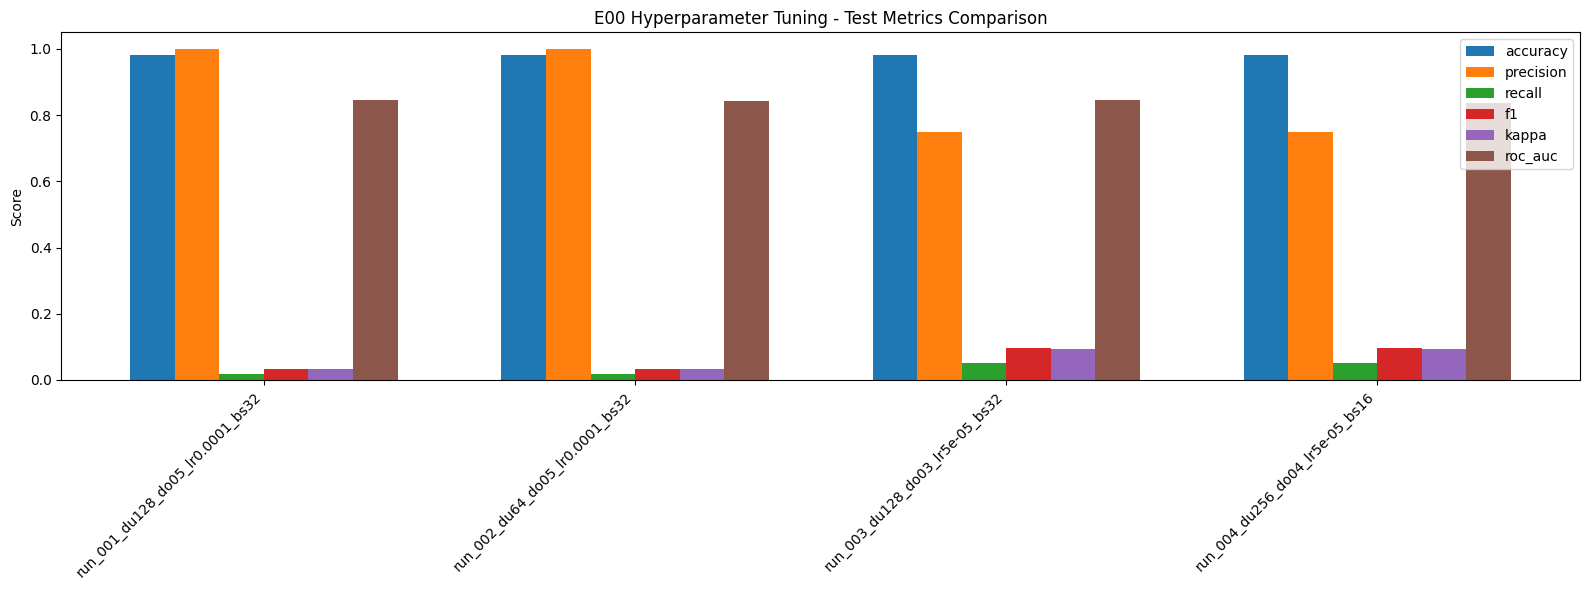

In [14]:
# =========================
# COMPARISON PLOT
# =========================

plot_cols = ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_kappa", "test_roc_auc"]
plot_df = results_df[["run_name"] + plot_cols].copy()

x = np.arange(len(plot_df))
width = 0.12

plt.figure(figsize=(16, 6))
for idx, col in enumerate(plot_cols):
    plt.bar(x + idx * width, plot_df[col].fillna(0), width=width, label=col.replace("test_", ""))

plt.xticks(x + width * (len(plot_cols)-1) / 2, plot_df["run_name"], rotation=45, ha="right")
plt.ylabel("Score")
plt.title("E00 Hyperparameter Tuning - Test Metrics Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(EXP_ROOT / "plots" / "E00_metrics_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# =========================
# EXPERIMENT MANIFEST
# =========================

manifest = {
    "experiment_id": "E00",
    "experiment_name": "Hyperparameter Tuning",
    "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "project_root": str(PROJECT_ROOT),
    "experiment_root": str(EXP_ROOT),
    "train_dir": str(TRAIN_DIR),
    "metadata_path": str(METADATA_PATH),
    "img_size": IMG_SIZE,
    "threshold": THRESHOLD,
    "use_hair_removal": USE_HAIR_REMOVAL,
    "use_segmentation": USE_SEGMENTATION,
    "num_configs": len(HYPERPARAM_GRID),
    "selection_metric": BEST_BY
}

save_json(manifest, EXP_ROOT / "summary" / "experiment_manifest.json")
print("E00 completed and saved.")

E00 completed and saved.
